# Notebook 2 — Modelo Clásico 1: LSTM
**Tarea:** Clasificación binaria de sentimiento en reseñas hoteleras en español  
**Dataset:** Big AHR (desbalanceado) y Balanced AHR  
**Modelo:** Long Short-Term Memory (LSTM) — 4 configuraciones

## 1. Configuración y Carga de Datos

In [1]:
import os, json, pickle, warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.utils import plot_model
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, f1_score,
                              precision_score, recall_score, accuracy_score)
from sklearn.utils.class_weight import compute_class_weight

warnings.filterwarnings('ignore')
np.random.seed(42); tf.random.set_seed(42)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)
    print(f"✅ GPU: {gpus[0].name}")
else:
    print("⚠️  CPU mode")

BASE_DIR = "results"
DIRS = {k: os.path.join(BASE_DIR, k) for k in ["data","figures","models","metrics"]}
for d in DIRS.values(): os.makedirs(d, exist_ok=True)


⚠️  CPU mode


In [2]:
def load_dataset(prefix):
    base = os.path.join(DIRS["data"], prefix)
    with open(f"{base}/tokenizer.pkl","rb") as f:
        tok = pickle.load(f)
    with open(f"{base}/meta.json") as f:
        meta = json.load(f)
    data = {k: np.load(f"{base}/{k}.npy")
            for k in ["X_train","y_train","X_val","y_val","X_test","y_test"]}
    return tok, meta, data

tok_big, meta_big, data_big = load_dataset("big_ahr")
tok_bal, meta_bal, data_bal = load_dataset("balanced_ahr")

for name, meta, d in [("Big AHR", meta_big, data_big),("Balanced AHR", meta_bal, data_bal)]:
    print(f"{name:20s}: train={d['X_train'].shape[0]:>5,}  "
          f"val={d['X_val'].shape[0]:>4,}  test={d['X_test'].shape[0]:>4,}")


Big AHR             : train=12,714  val=1,589  test=1,590
Balanced AHR        : train=4,272  val= 534  test= 535


In [3]:
def get_class_weights(y_train):
    cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    return {0: cw[0], 1: cw[1]}

def make_callbacks(model_name, patience=5):
    ckpt_path = os.path.join(DIRS["models"], f"{model_name}_best.keras")
    return [
        callbacks.EarlyStopping(monitor='val_loss', patience=patience,
                                restore_best_weights=True, verbose=0),
        callbacks.ModelCheckpoint(ckpt_path, save_best_only=True,
                                  monitor='val_loss', verbose=0),
        callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                    patience=3, min_lr=1e-6, verbose=0),
    ]

def train_model(model, config, data, dataset_name, use_class_weight=False):
    X_tr, y_tr   = data['X_train'], data['y_train']
    X_val, y_val = data['X_val'],   data['y_val']
    X_te, y_te   = data['X_test'],  data['y_test']

    model_id = f"{config['name']}_{dataset_name}"
    cw = get_class_weights(y_tr) if use_class_weight else None

    hist = model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=config['epochs'],
        batch_size=config['batch_size'],
        class_weight=cw,
        callbacks=make_callbacks(model_id, patience=config.get('patience',5)),
        verbose=1
    )
    return hist, model_id

def evaluate_model(model, data, model_id):
    X_te, y_te = data['X_test'], data['y_test']
    y_prob = model.predict(X_te, verbose=0).ravel()
    y_pred = (y_prob >= 0.5).astype(int)

    metrics = {
        "accuracy":  float(accuracy_score(y_te, y_pred)),
        "precision": float(precision_score(y_te, y_pred, zero_division=0)),
        "recall":    float(recall_score(y_te, y_pred, zero_division=0)),
        "f1":        float(f1_score(y_te, y_pred, zero_division=0)),
        "roc_auc":   float(roc_auc_score(y_te, y_prob)),
    }
    print(f"\n  [{model_id}]")
    for k, v in metrics.items():
        print(f"    {k:12s}: {v:.4f}")
    return metrics, y_pred, y_prob, y_te

def save_metrics(all_results, model_type):
    path = os.path.join(DIRS["metrics"], f"{model_type}_results.json")
    with open(path, "w") as f:
        json.dump(all_results, f, indent=2)
    print(f"✅ Métricas guardadas: {path}")

def plot_training_curves(histories, model_type):
    n = len(histories)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4*n))
    if n == 1: axes = [axes]
    fig.suptitle(f"Curvas de Entrenamiento — {model_type}", fontsize=14, fontweight='bold')
    for i, (name, hist) in enumerate(histories):
        h = hist.history
        axes[i][0].plot(h['loss'],     label='Train Loss',  color='#e74c3c')
        axes[i][0].plot(h['val_loss'], label='Val Loss',    color='#3498db')
        axes[i][0].set_title(f"{name} — Loss"); axes[i][0].legend()
        axes[i][0].set_xlabel("Época"); axes[i][0].set_ylabel("Loss")

        axes[i][1].plot(h['accuracy'],     label='Train Acc', color='#27ae60')
        axes[i][1].plot(h['val_accuracy'], label='Val Acc',   color='#8e44ad')
        axes[i][1].set_title(f"{name} — Accuracy"); axes[i][1].legend()
        axes[i][1].set_xlabel("Época"); axes[i][1].set_ylabel("Accuracy")

    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_training_curves.png")
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show(); print(f"✅ {path}")

def plot_confusion_matrices(results_list, model_type):
    n = len(results_list)
    cols = min(n, 4)
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))
    axes = np.array(axes).flatten()
    fig.suptitle(f"Matrices de Confusión — {model_type}", fontsize=14, fontweight='bold')
    for i, (name, y_te, y_pred) in enumerate(results_list):
        cm = confusion_matrix(y_te, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i],
                    cmap='Blues', cbar=False,
                    xticklabels=['Neg','Pos'], yticklabels=['Neg','Pos'])
        axes[i].set_title(name, fontsize=10, fontweight='bold')
        axes[i].set_xlabel("Predicho"); axes[i].set_ylabel("Real")
    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_confusion_matrices.png")
    plt.savefig(path, dpi=130, bbox_inches='tight')
    plt.show(); print(f"✅ {path}")

def plot_roc_curves(results_list, model_type):
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))
    for (name, y_te, y_prob), clr in zip(results_list, colors):
        fpr, tpr, _ = roc_curve(y_te, y_prob)
        auc = roc_auc_score(y_te, y_prob)
        ax.plot(fpr, tpr, color=clr, lw=2, label=f"{name} (AUC={auc:.3f})")
    ax.plot([0,1],[0,1],'--', color='gray', lw=1)
    ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
    ax.set_title(f"Curvas ROC — {model_type}", fontsize=14, fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    plt.tight_layout()
    path = os.path.join(DIRS["figures"], f"{model_type}_roc_curves.png")
    plt.savefig(path, dpi=130, bbox_inches='tight'); plt.show()

def summarize_results(all_results, model_type):
    import pandas as pd
    rows = []
    for res in all_results:
        rows.append({
            "Modelo":    res["config"],
            "Dataset":   res["dataset"],
            "Accuracy":  res["metrics"]["accuracy"],
            "Precision": res["metrics"]["precision"],
            "Recall":    res["metrics"]["recall"],
            "F1-Score":  res["metrics"]["f1"],
            "ROC-AUC":   res["metrics"]["roc_auc"],
        })
    df = pd.DataFrame(rows)
    print("\n" + df.to_string(index=False))
    path = os.path.join(DIRS["metrics"], f"{model_type}_summary.csv")
    df.to_csv(path, index=False)
    print(f"\n✅ Tabla guardada: {path}")
    return df


## 2. Definición de Arquitecturas LSTM

Se proponen **4 configuraciones** de menor a mayor complejidad:

| Config | Descripción |
|--------|-------------|
| C1 | LSTM simple, embedding pequeño |
| C2 | LSTM medio con dropout |
| C3 | LSTM apilado (stacked) |
| C4 | LSTM profundo con regularización fuerte |

In [4]:
# ── Configuraciones LSTM (de menor a mayor complejidad) ──
LSTM_CONFIGS = [
    {
        "name":        "LSTM_C1_Simple",
        "vocab_size":   5000,
        "embed_dim":     64,
        "lstm_units":   [64],
        "dropout":       0.20,
        "rec_dropout":   0.10,
        "dense_units":  [32],
        "lr":            1e-3,
        "batch_size":    64,
        "epochs":        20,
        "patience":       5,
        "description": "LSTM simple — baseline rápido"
    },
    {
        "name":        "LSTM_C2_Medium",
        "vocab_size":  10000,
        "embed_dim":   128,
        "lstm_units":  [128],
        "dropout":      0.30,
        "rec_dropout":  0.20,
        "dense_units": [64],
        "lr":           1e-3,
        "batch_size":   128,
        "epochs":        25,
        "patience":       6,
        "description": "LSTM mediano con dropout"
    },
    {
        "name":        "LSTM_C3_Stacked",
        "vocab_size":  15000,
        "embed_dim":   128,
        "lstm_units":  [128, 64],
        "dropout":      0.40,
        "rec_dropout":  0.25,
        "dense_units": [64, 32],
        "lr":           5e-4,
        "batch_size":   128,
        "epochs":        30,
        "patience":       7,
        "description": "LSTM apilado (2 capas)"
    },
    {
        "name":        "LSTM_C4_Deep",
        "vocab_size":  20000,
        "embed_dim":   256,
        "lstm_units":  [256, 128, 64],
        "dropout":      0.50,
        "rec_dropout":  0.30,
        "dense_units": [128, 64],
        "lr":           3e-4,
        "batch_size":   256,
        "epochs":        35,
        "patience":       8,
        "description": "LSTM profundo + regularización L2"
    },
]

def build_lstm(config, vocab_size, max_len=150):
    """Construye un modelo LSTM según la configuración dada."""
    # vocab_size viene del meta del tokenizador (el real, no el del config)
    inp = layers.Input(shape=(max_len,), name="input")
    x   = layers.Embedding(vocab_size,          # siempre el real del tokenizador
                            config['embed_dim'],  # embed_dim sí varía por config
                            mask_zero=True, name="embedding")(inp)
    x   = layers.SpatialDropout1D(0.2)(x)

    lstm_units = config['lstm_units']
    for i, units in enumerate(lstm_units):
        return_seq = (i < len(lstm_units) - 1)
        x = layers.LSTM(units,
                        dropout=config['dropout'],
                        recurrent_dropout=config['rec_dropout'],
                        return_sequences=return_seq,
                        name=f"lstm_{i+1}")(x)
        if return_seq:
            x = layers.Dropout(config['dropout'])(x)

    for i, units in enumerate(config.get('dense_units', [])):
        reg = tf.keras.regularizers.l2(1e-4) if i == 0 and len(config['lstm_units']) == 3 else None
        x = layers.Dense(units, activation='relu',
                         kernel_regularizer=reg, name=f"dense_{i+1}")(x)
        x = layers.Dropout(config['dropout'] * 0.5)(x)

    out = layers.Dense(1, activation='sigmoid', name="output")(x)
    model = models.Model(inp, out, name=config['name'])
    model.compile(optimizer=optimizers.Adam(config['lr']),
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

# Mostrar resumen de la Config 3 como ejemplo
m_example = build_lstm(LSTM_CONFIGS[2], meta_big['vocab_size'])
m_example.summary()

Model: "LSTM_C3_Stacked"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 150)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 150, 128)  │  2,560,000 │ input[0][0]       │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 150, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 150)       │          0 │ input[0][0]       │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 150, 128)  │    131,584 │ spatial_dropout1… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 150, 128)  │          0 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 64)        │     49,408 │ dropout[0][0],    │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      4,160 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 32)        │      2,080 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32)        │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output (Dense)      │ (None, 1)         │         33 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,747,265 (10.48 MB)

 Trainable params: 2,747,265 (10.48 MB)

 Non-trainable params: 0 (0.00 B)

## 3. Entrenamiento — Dataset Balanceado

In [5]:
all_results  = []
all_histories = []
conf_matrix_data = []
roc_data         = []

DATASET_PAIRS = [
    ("balanced", data_bal, meta_bal, False),   # No class_weight (ya balanceado)
    ("big_ahr",  data_big, meta_big, True),    # class_weight para imbalance
]

for ds_name, data, meta, use_cw in DATASET_PAIRS:
    vs = meta['vocab_size']
    max_len = meta['max_len']
    print(f"\n{'='*60}")
    print(f"  DATASET: {ds_name.upper()}")
    print(f"{'='*60}")

    for cfg in LSTM_CONFIGS:
        tf.keras.backend.clear_session()
        print(f"\n▶ {cfg['name']} | {cfg['description']}")
        model = build_lstm(cfg, vs, max_len)

        hist, model_id = train_model(model, cfg, data, ds_name, use_class_weight=use_cw)
        mets, y_pred, y_prob, y_te = evaluate_model(model, data, model_id)

        all_results.append({
            "config":  cfg['name'],
            "dataset": ds_name,
            "description": cfg['description'],
            "params": model.count_params(),
            "metrics": mets,
            "history": {k: [float(v) for v in vals]
                        for k, vals in hist.history.items()}
        })
        all_histories.append((model_id, hist))
        conf_matrix_data.append((model_id, y_te, y_pred))
        roc_data.append((model_id, y_te, y_prob))

        # Guardar modelo
        model.save(os.path.join(DIRS["models"], f"{model_id}.keras"))
        print(f"  ✅ Modelo guardado | Params: {model.count_params():,}")

print("\n✅ Entrenamiento completado")


  DATASET: BALANCED

▶ LSTM_C1_Simple | LSTM simple — baseline rápido
Epoch 1/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - accuracy: 0.8305 - loss: 0.4438 - val_accuracy: 0.9551 - val_loss: 0.1931 - learning_rate: 0.0010
Epoch 2/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9635 - loss: 0.1453 - val_accuracy: 0.9850 - val_loss: 0.0748 - learning_rate: 0.0010
Epoch 3/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9932 - loss: 0.0327 - val_accuracy: 0.9888 - val_loss: 0.0495 - learning_rate: 0.0010
Epoch 4/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - accuracy: 0.9972 - loss: 0.0147 - val_accuracy: 0.9906 - val_loss: 0.0443 - learning_rate: 0.0010
Epoch 5/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.9988 - loss: 0.0092 - val_accuracy: 0.9906 - val_loss: 0.0355 - learning_rate: 0.0010
Epoch 6/20
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - accuracy: 0.9993 - loss: 0.0074 - val_accuracy: 0.9925 - val_loss: 0.0382 - learning_rate: 0.0010
Epoch 7/20
67/67 ━━━━━━

## 4. Visualizaciones

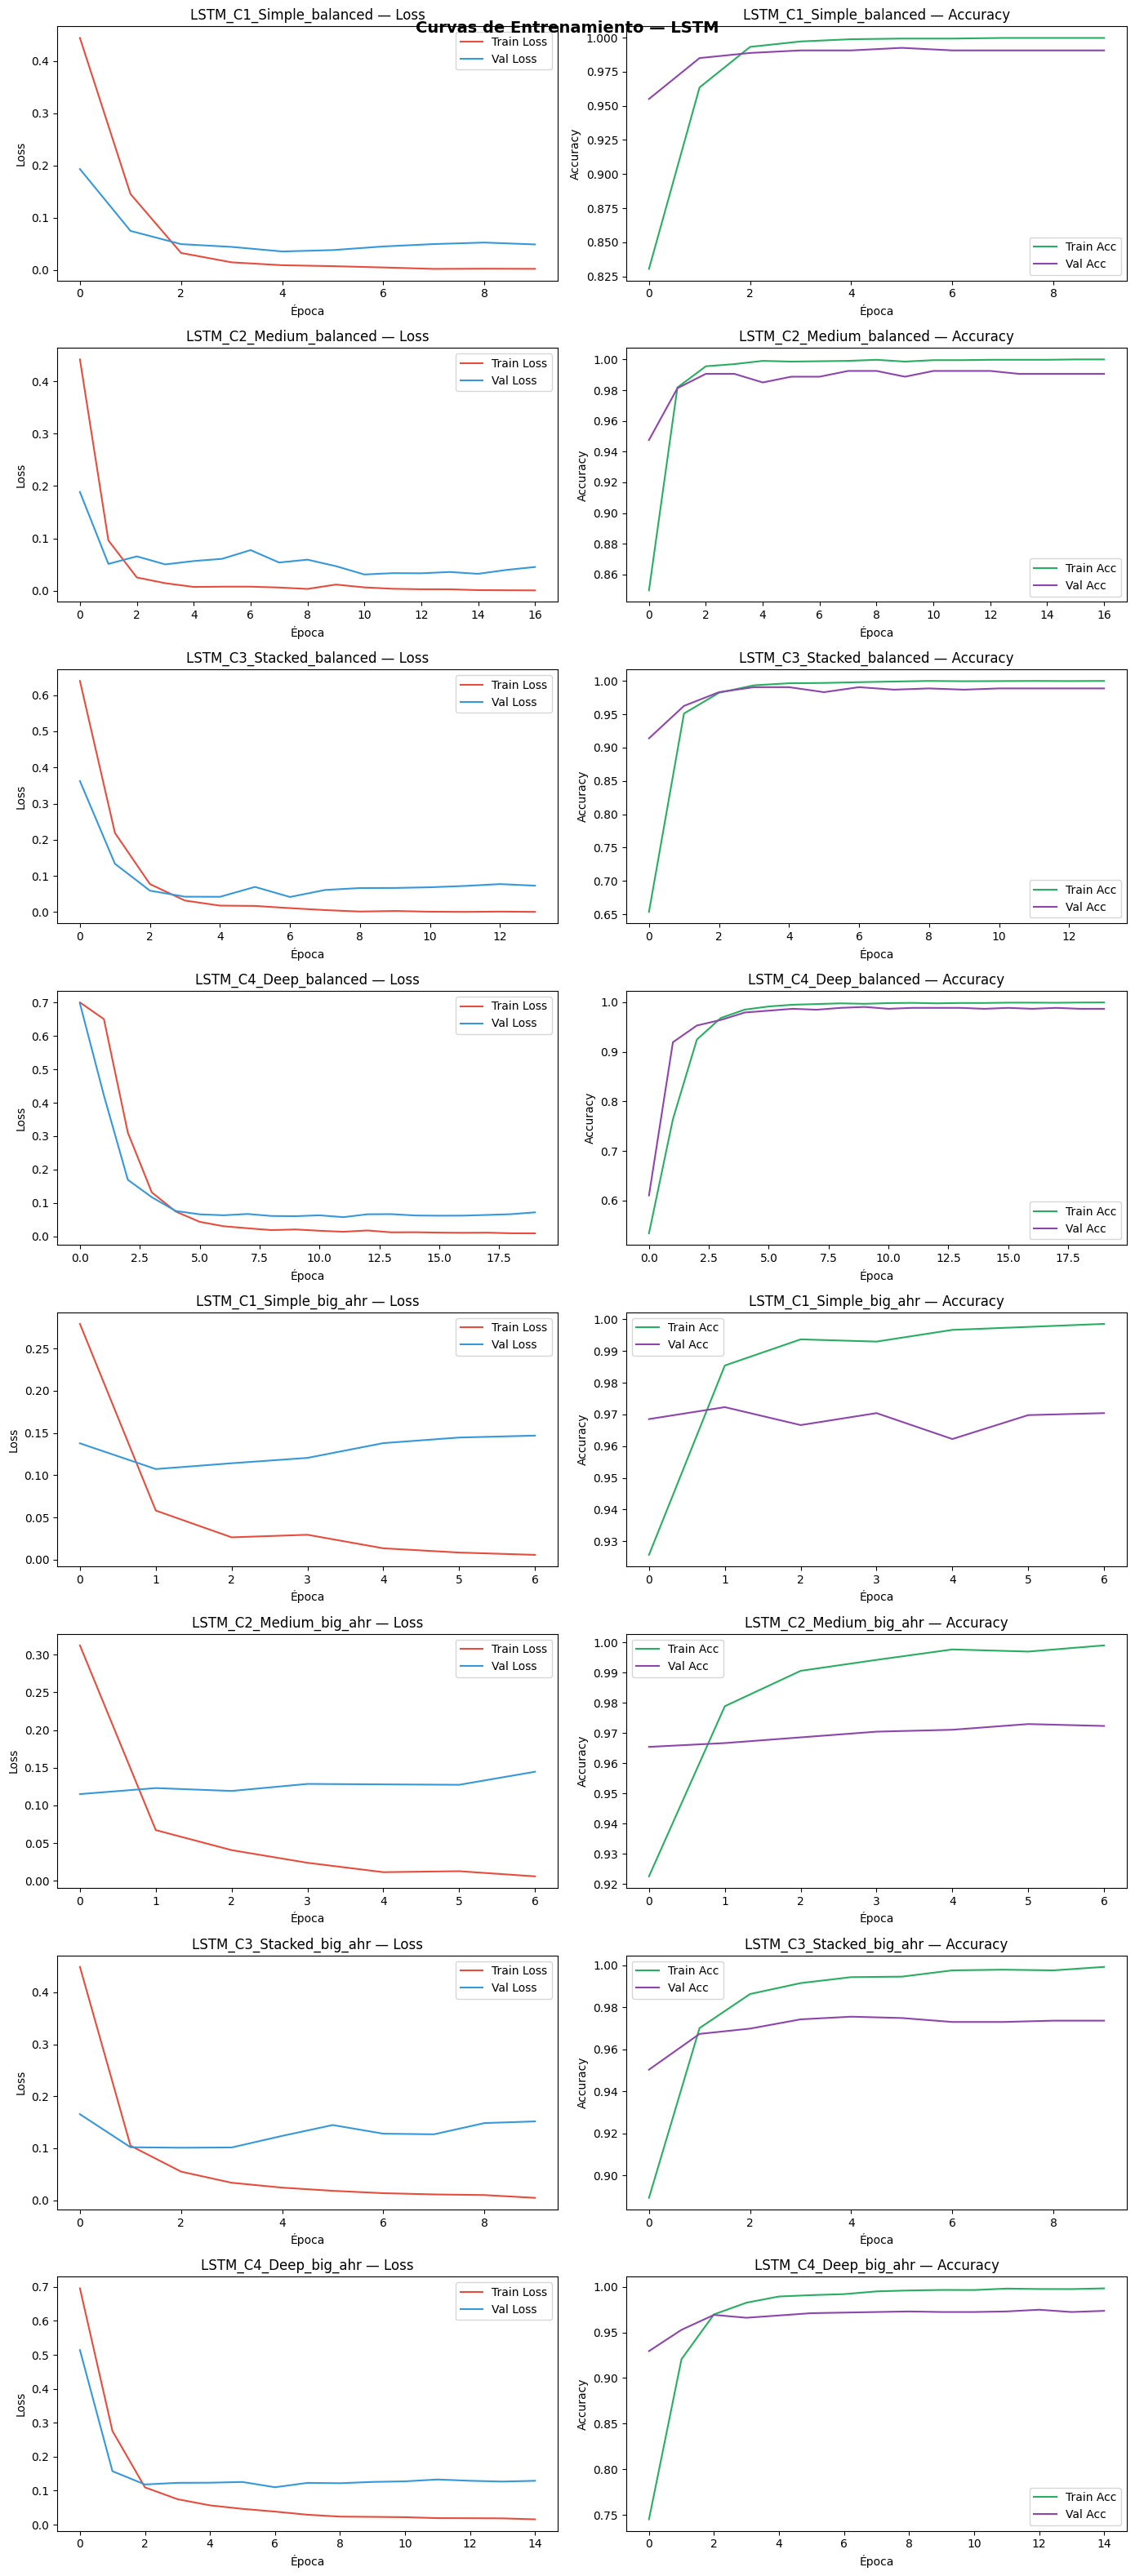

✅ results/figures/LSTM_training_curves.png


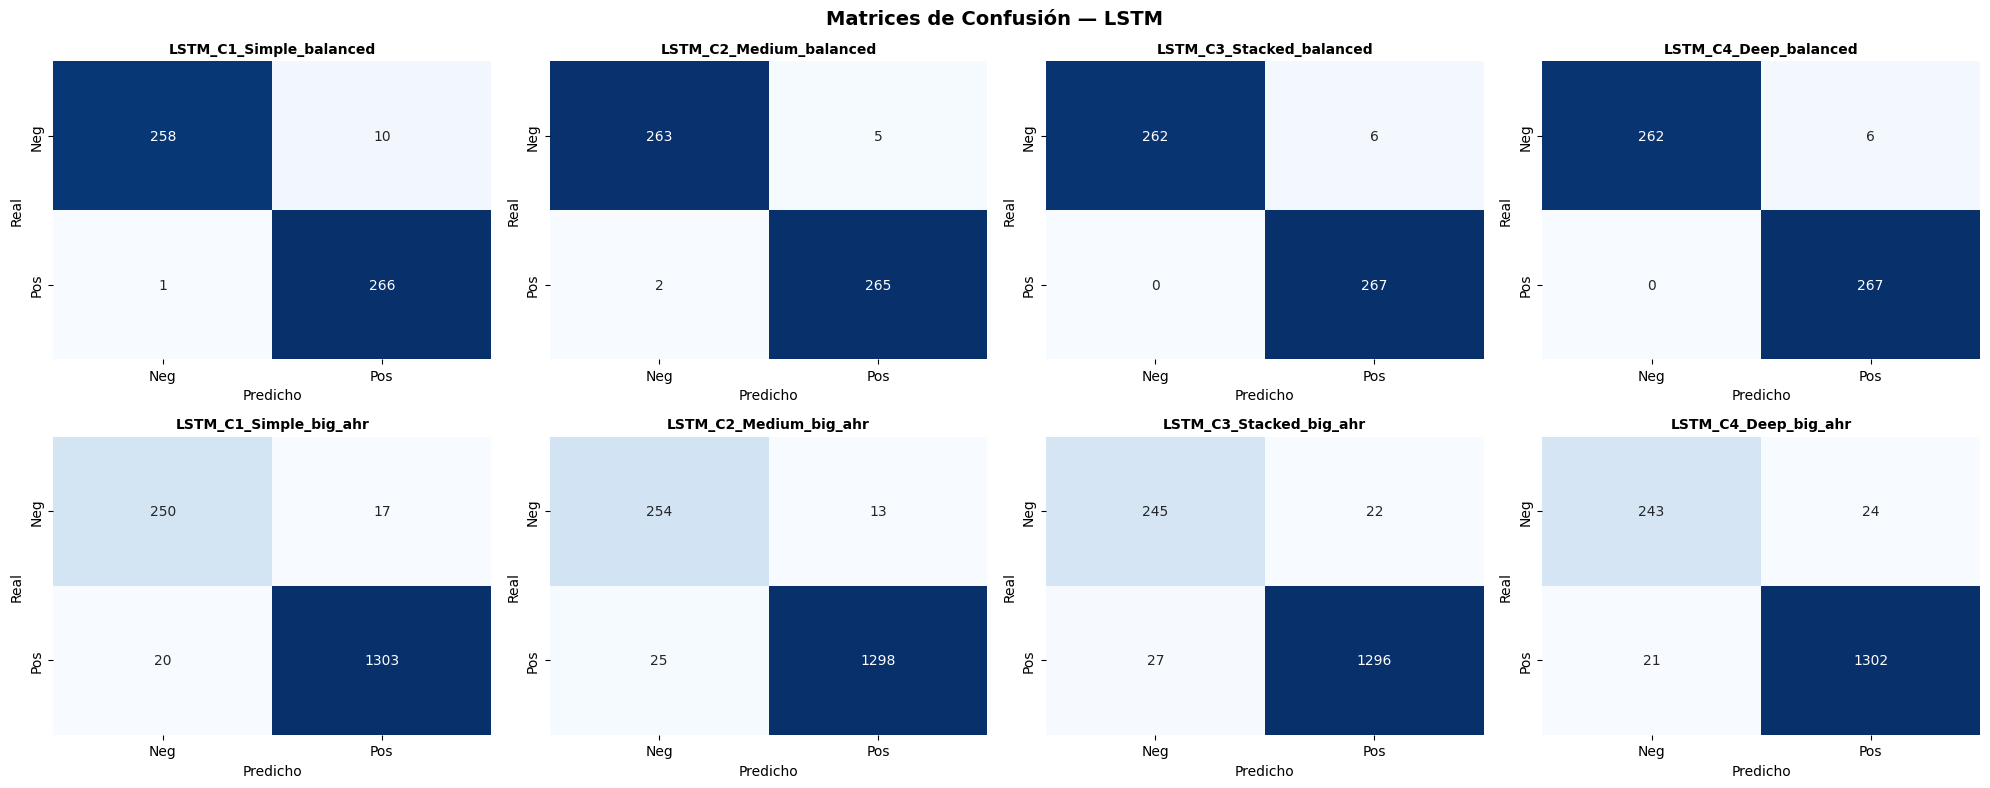

✅ results/figures/LSTM_confusion_matrices.png


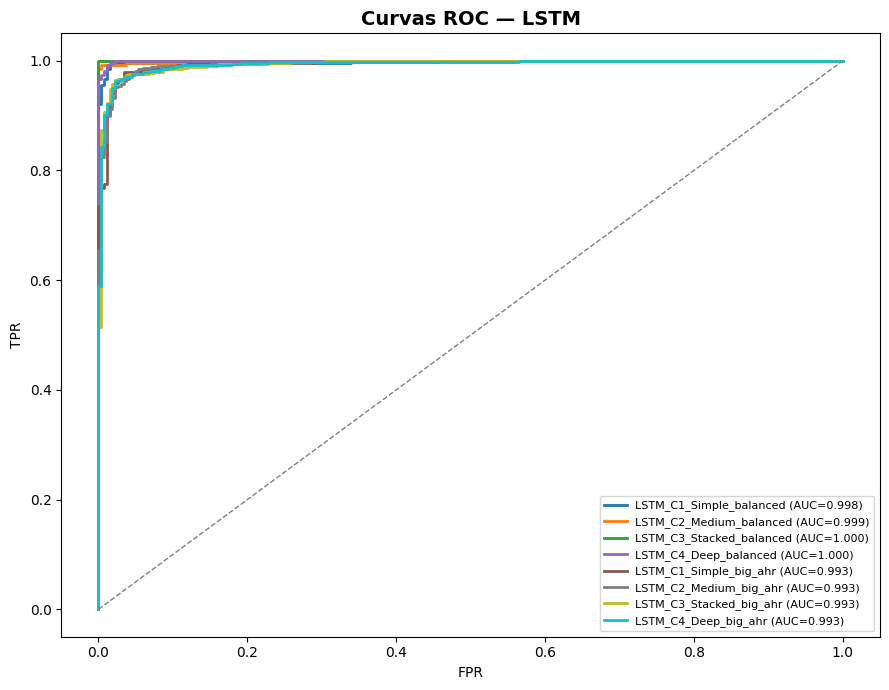

In [6]:
plot_training_curves(all_histories, "LSTM")
plot_confusion_matrices(conf_matrix_data, "LSTM")
plot_roc_curves(roc_data, "LSTM")

## 5. Tabla Comparativa y Guardado

In [ ]:
save_metrics(all_results, "LSTM")
df_summary = summarize_results(all_results, "LSTM")

# Barplot F1-Score
import pandas as pd
fig, ax = plt.subplots(figsize=(13, 5))
pivot = df_summary.pivot(index="Modelo", columns="Dataset", values="F1-Score")
pivot.plot(kind='bar', ax=ax, colormap='viridis', edgecolor='white', width=0.7)
ax.set_title("F1-Score por Configuración LSTM y Dataset", fontsize=14, fontweight='bold')
ax.set_ylabel("F1-Score"); ax.set_ylim(0.5, 1.0)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title="Dataset"); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(DIRS["figures"], "LSTM_f1_comparison.png"), dpi=130)
plt.show()